In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm import tqdm

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
data = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data["label"].value_counts()

1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: label, dtype: int64

In [4]:
x = data.drop("label", axis = 1)
y = data["label"]

In [5]:
#OVERSAMPLING TO REMOVE CLASS IMBALANCE (ALTHOUGH NOT SIGNIFICANT HERE)¶

In [6]:
from imblearn.over_sampling import RandomOverSampler

oversample = RandomOverSampler(sampling_strategy='minority')
xover, yover = oversample.fit_resample(x, y)
len(xover), len(yover)

(42889, 42889)

In [7]:
#PREPROCESSING DATA

In [8]:
 #DEFINING A FUNCTION TO PREPROCESS THE DATA
# CONVERTING THEM TO SHAPE(NUMBER,PIXEL,PIXEL)
def preprocess(x, y):
    digits = []
    labels = []
    for i in tqdm(range(0,len(x))):
        # TAKING ONE DIGIT OUT OF THE DATAFRAME
        digit = np.array(x.iloc[i:i+1,:])
        # RESHAPING TO MAKE AN IMAGE OF 28 X 28 PIXELS
        digit = digit.reshape(28,28)
        # EXTRACTING THE LABELS 
        label = y[i]
        
        digits.append(digit)
        labels.append(label)
     # MAKING AN ARRAY OF DATA
    digits = np.array(digits)
    labels = np.array(labels)
    return digits,labels

In [9]:
digits,labels = preprocess(xover, yover)

100%|██████████| 42889/42889 [09:24<00:00, 75.95it/s]


In [10]:
digits.shape, labels.shape

((42889, 28, 28), (42889,))

In [11]:
#VISUALISING SOME SAMPLE IMAGES

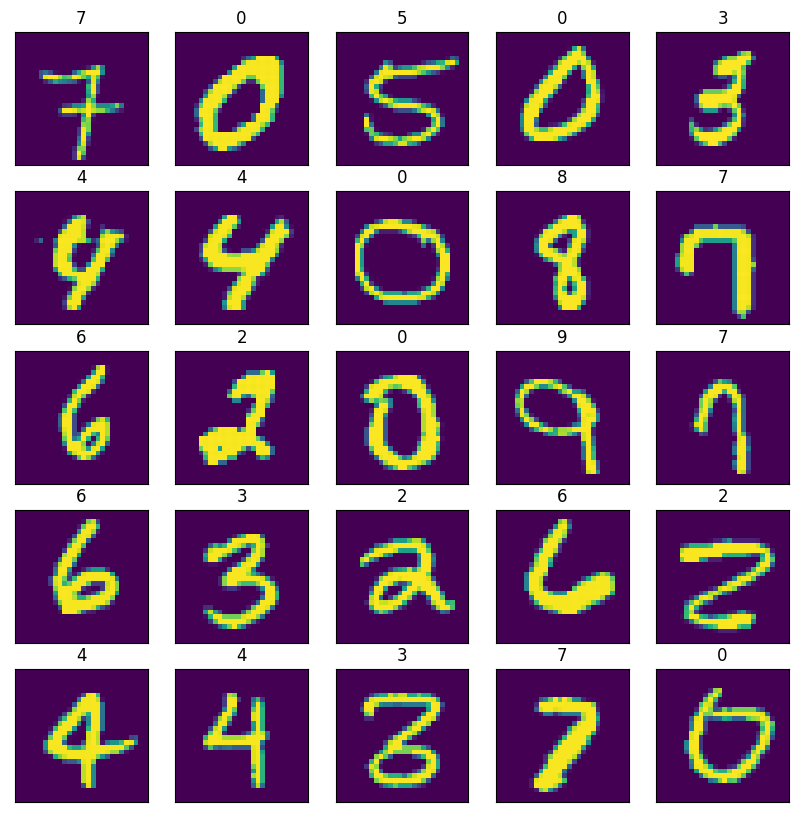

In [12]:
# SEEING OUR AUGMENTED DATA
import random
fig,ax = plt.subplots(5,5,figsize=(10,10))
for i in range(0,5):
    for j in range(0,5):
        n = random.randint(0,len(digits))
        ax[i][j].imshow(digits[n])
        ax[i][j].set_xticks([])
        ax[i][j].set_yticks([])
        ax[i][j].set_title(f"{labels[n]}")

In [13]:
#BUILDING OUR MODEL USING CNN

In [14]:
from keras import layers

def cnn_mnist_model():
    cnn_mnist_model = tf.keras.Sequential(
        [
            layers.InputLayer(input_shape=(28, 28, 1)),
            # BLOCK 1
            layers.Conv2D(filters=32, kernel_size=3, strides=1, padding="valid", use_bias=False, kernel_initializer="he_normal"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Conv2D(filters=32, kernel_size=3, strides=1, padding="valid", use_bias=False, kernel_initializer="he_normal"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
            layers.BatchNormalization(),
            layers.Dropout(0.4),
            # BLOCK 2
            layers.Conv2D(filters=64, kernel_size=3, strides=1, padding="valid", use_bias=False, kernel_initializer="he_normal",),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Conv2D(filters=64, kernel_size=3, strides=1, padding="valid", use_bias=False, kernel_initializer="he_normal",),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
            layers.BatchNormalization(),
            layers.Dropout(0.4),
            #
            layers.Flatten(),
            layers.Dense(128, use_bias=False, kernel_initializer="he_normal"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Dropout(0.5),
            layers.Dense(10, activation="softmax"),
        ]
    )
    cnn_mnist_model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="nadam",
        metrics=["accuracy"],
    )
    return cnn_mnist_model

cnn_mnist_model = cnn_mnist_model()

In [15]:
checkpointer = tf.keras.callbacks.ModelCheckpoint('/kaggle/working/MNISTWeights.h5', verbose=1, save_best_only=True)

cnn_mnist_model.fit(digits, labels,
          epochs = 10,
          validation_split=0.15,
          batch_size=32,
         callbacks = checkpointer)


Epoch 1/10
1139/1140 [============================>.] - ETA: 0s - loss: 0.3074 - accuracy: 0.9073
Epoch 1: val_loss improved from inf to 0.06096, saving model to /kaggle/working/MNISTWeights.h5
1140/1140 [==============================] - 74s 61ms/step - loss: 0.3074 - accuracy: 0.9073 - val_loss: 0.0610 - val_accuracy: 0.9790
Epoch 2/10
1139/1140 [============================>.] - ETA: 0s - loss: 0.1074 - accuracy: 0.9681
Epoch 2: val_loss improved from 0.06096 to 0.04298, saving model to /kaggle/working/MNISTWeights.h5
1140/1140 [==============================] - 70s 61ms/step - loss: 0.1074 - accuracy: 0.9681 - val_loss: 0.0430 - val_accuracy: 0.9876
Epoch 3/10
1139/1140 [============================>.] - ETA: 0s - loss: 0.0877 - accuracy: 0.9738
Epoch 3: val_loss improved from 0.04298 to 0.03933, saving model to /kaggle/working/MNISTWeights.h5
1140/1140 [==============================] - 71s 62ms/step - loss: 0.0877 - accuracy: 0.9737 - val_loss: 0.0393 - val_accuracy: 0.9869
Epoch

In [16]:
ypreds = cnn_mnist_model.predict(digits[:20000])
# TAKING MAXIMUM PROBABILITIES TO MAKE OUR PREDICTIONS
preds=[]
for i in range(0,len(ypreds)):
    preds.append(np.argmax(ypreds[i]))

# MAKING A DATAFRAME TO ACCES TRUE LABELS AND PREDICTED LABELS WITH EASE
df = pd.DataFrame({"TRUE":labels[:20000],"PREDS":preds})
df

625/625 [==============================] - 8s 12ms/step


,TRUE,PREDS
0,1,1
1,0,0
2,1,1
3,4,4
4,0,0
...,...,...
19995,9,9
19996,9,9
19997,6,6
19998,8,8


In [17]:
from sklearn.metrics import classification_report
rep = pd.DataFrame(classification_report(df["TRUE"],df["PREDS"],output_dict=True))
rep

,0,1,2,3,4,5,6,7,8,9,accuracy,macro avg,weighted avg
precision,0.998965,0.997790,0.997509,0.999037,0.996443,0.997769,0.998989,0.990398,0.992208,0.996962,0.9966,0.996607,0.996608
recall,0.998965,0.996028,0.996020,0.997115,0.994926,0.997213,0.997477,0.996618,0.997389,0.994444,0.9966,0.996620,0.996600
f1-score,0.998965,0.996908,0.996764,0.998075,0.995684,0.997491,0.998233,0.993499,0.994792,0.995702,0.9966,0.996611,0.996602
support,1932.000000,2266.000000,2010.000000,2080.000000,1971.000000,1794.000000,1982.000000,2070.000000,1915.000000,1980.000000,0.9966,20000.000000,20000.000000


In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(df["TRUE"],df["PREDS"])
cm

array([[1930,    0,    0,    0,    0,    0,    0,    0,    2,    0],
       [   0, 2257,    1,    0,    0,    0,    0,    7,    1,    0],
       [   0,    1, 2002,    0,    0,    0,    0,    4,    3,    0],
       [   0,    0,    0, 2074,    0,    1,    0,    0,    4,    1],
       [   0,    1,    0,    0, 1961,    0,    1,    4,    1,    3],
       [   0,    0,    0,    1,    0, 1789,    1,    0,    3,    0],
       [   1,    0,    0,    0,    2,    1, 1977,    0,    1,    0],
       [   0,    3,    4,    0,    0,    0,    0, 2063,    0,    0],
       [   1,    0,    0,    0,    2,    0,    0,    0, 1910,    2],
       [   0,    0,    0,    1,    3,    2,    0,    5,    0, 1969]])

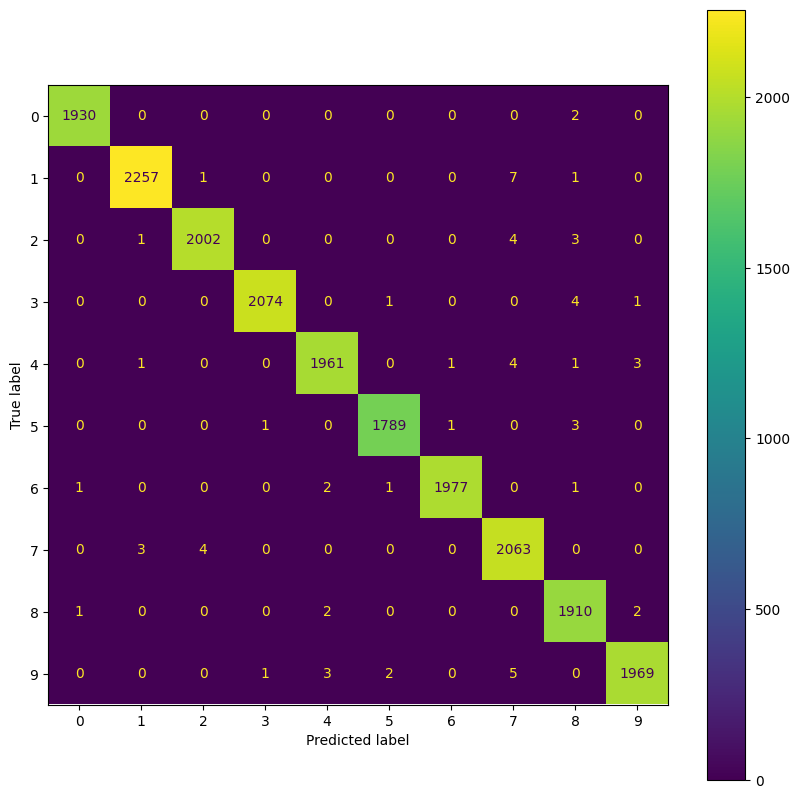

In [19]:
cmd = ConfusionMatrixDisplay(cm)
fig, ax = plt.subplots(figsize=(10,10))
cmd.plot(ax=ax)

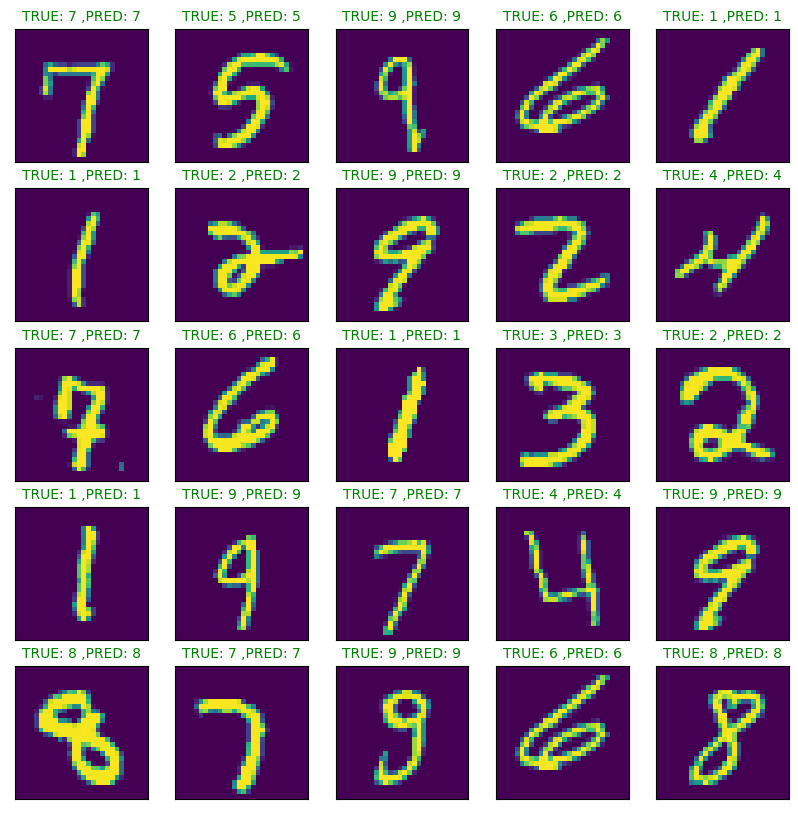

In [20]:
fig,ax = plt.subplots(5,5,figsize=(10,10))
for i in range(0,5):
    for j in range(0,5):
        n = random.randint(0,100)
        ax[i][j].imshow(digits[:20000][n])
        ax[i][j].set_xticks([])
        ax[i][j].set_yticks([])
        if labels[:20000][n] != preds[n]:
            ax[i][j].set_title(f"TRUE: {labels[:20000][n]} ,PRED: {preds[n]}",color = "red",fontsize = 10)
        else:
            ax[i][j].set_title(f"TRUE: {labels[:20000][n]} ,PRED: {preds[n]}",color = "green",fontsize = 10)

In [21]:
test_df = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")
test_df

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
def preprocess_test(df):
    digits = []
    for i in tqdm(range(0,len(df))):
        digit = np.array(df.iloc[i:i+1,:])
        digit = digit.reshape(28,28)
        digits.append(digit)

    digits = np.array(digits)
    return digits

test_digits = preprocess_test(test_df)

100%|██████████| 28000/28000 [00:02<00:00, 12700.00it/s]


In [23]:
ypreds_test = cnn_mnist_model.predict(test_digits)
test_preds=[]
for i in tqdm(range(0,len(ypreds_test))):
    test_preds.append(np.argmax(ypreds_test[i]))
    
pred_df = pd.DataFrame({"ImageId":test_df.index+1, "Label":test_preds})
pred_df

875/875 [==============================] - 11s 13ms/step


100%|██████████| 28000/28000 [00:00<00:00, 186009.02it/s]


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


In [24]:
pred_df.to_csv("submission.csv", index = False)